## <span style = 'color:coral'>Batch gradient Descent</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.pop('Extracurricular Activities')

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: Extracurricular Activities, Length: 10000, dtype: object

In [4]:
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [5]:
df.rename(columns = {
      'Hours Studied':'study_hrs',
      'Previous Scores':'prev_score',
      'Sleep Hours':'sleep_hrs',
      'Sample Question Papers Practiced':'ques_paper',
      'Performance Index':'perf_index'
},inplace=True)

In [6]:
df.columns

Index(['study_hrs', 'prev_score', 'sleep_hrs', 'ques_paper', 'perf_index'], dtype='object')

In [7]:
df.isna().sum()

study_hrs     0
prev_score    0
sleep_hrs     0
ques_paper    0
perf_index    0
dtype: int64

In [8]:
# features and target
x = df.iloc[:,0:4]
y = df.iloc[:, -1]

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

In [9]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [10]:
# custom class
class BGD:
    def __init__(self, learning_rate, epochs):
        self.coef_ = None
        self.intercept_ = None
        self.epochs = epochs
        self.n = learning_rate
        self.loss_list = []
    
    def fit(self, x_train, y_train):
        self.coef_ = np.ones(x_train.shape[1])
        self.intercept_ = 0

        for i in range(self.epochs):
            y_pred = self.intercept_ + np.dot(x_train, self.coef_)

            # udpate self.intercept_
            grad_intercept_ = (-2/x_train.shape[0]) * np.sum(y_train - y_pred)
            self.intercept_ -= (self.n * grad_intercept_)

            # update self.coef_
            grad_coef_ = (-2/x_train.shape[0]) * np.dot((y_train - y_pred), x_train)
            self.coef_ -= (self.n * grad_coef_)

            loss = np.mean((y_pred - y_train)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        print('final parameters...')
        print('coef_ = ',self.coef_)
        print('intercept_ = ',self.intercept_)
    
    def predict(self,x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)


In [11]:
batch = BGD(0.01, 100)
batch.fit(x_train, y_train)

step 0 | loss = 2.2921996285927113
step 1 | loss = 2.200408843157042
step 2 | loss = 2.112312807925357
step 3 | loss = 2.0277627866986645
step 4 | loss = 1.9466160314287044
step 5 | loss = 1.8687355411096955
step 6 | loss = 1.7939898303790507
step 7 | loss = 1.722252707436086
step 8 | loss = 1.6534030609034507
step 9 | loss = 1.5873246552711546
step 10 | loss = 1.523905934577548
step 11 | loss = 1.4630398339955513
step 12 | loss = 1.4046235990057692
step 13 | loss = 1.3485586118509707
step 14 | loss = 1.2947502249786966
step 15 | loss = 1.2431076011905846
step 16 | loss = 1.1935435602283266
step 17 | loss = 1.145974431537053
step 18 | loss = 1.1003199129573764
step 19 | loss = 1.0565029351073487
step 20 | loss = 1.0144495312252002
step 21 | loss = 0.9740887122529507
step 22 | loss = 0.9353523469498539
step 23 | loss = 0.8981750468331177
step 24 | loss = 0.8624940557515156
step 25 | loss = 0.8282491439053233
step 26 | loss = 0.7953825061335331
step 27 | loss = 0.7638386642965077
step 28

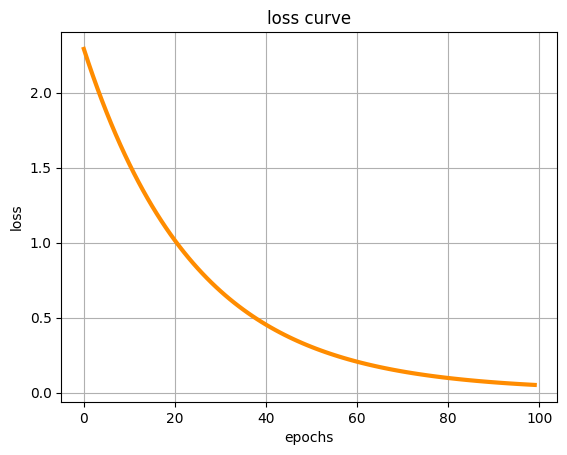

In [12]:
# loss curve
plt.plot(range(batch.epochs), batch.loss_list, color = 'darkorange',lw = 3)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss curve')
plt.grid(True)
plt.show()

In [14]:
y_pred = batch.predict(x_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.9510852637232853